# Teoria da Decisão & Inferência Bayesiana Aplicada: Quina
### Modelagem Probabilística, Geometria do Acaso e Decisão Ótima sob Incerteza

> **Fundamentação Epistemológica e Teórica:**
> Este estudo constitui um laboratório analítico e computacional que transpõe para o contexto empírico das loterias da Caixa Econômica Federal os fundamentos formais da **Teoria da Decisão Estatística sob Incerteza**, da **Inferência Bayesiana** e da **Combinatória Estocástica**, integrando quatro pilares teóricos da literatura científica:
>
> 1. **Teoria da Decisão e Inferência Bayesiana (Luís Gustavo Esteves, Rafael Izbicki e Rafael Bassi Stern):**
>    A formulação de uma aposta deixa de ser tratada como mero palpite empírico e é rigorosamente formalizada como o problema de decisão sob incerteza $(\mathcal{A}, \Theta, P, U)$. Sob o Teorema da Utilidade Esperada, a escolha racional é guiada pela **Alternativa de Bayes**, que seleciona a ação que maximiza a utilidade esperada a posteriori a partir da atualização de crenças via modelo conjugado Beta-Binomial.
>
> 2. **A Geometria do Acaso e Gabaritos Diofantinos de Cores (Renato Gianella, 2013):**
>    Em *The Geometry of Chance: Lotto Numbers Follow a Predicted Pattern*, Gianella demonstra que, embora todo bilhete individual (micro-estado) possua estritamente a mesma probabilidade $1/\binom{N}{k}$, as partições do espaço amostral em gabaritos de cores geram macro-estados com probabilidades combinatórias drasticamente desiguais. Pela Lei dos Grandes Números de Jacques Bernoulli, os sorteios convergem inevitavelmente para os gabaritos de maior entropia e probabilidade combinatória acumulada.
>
> 3. **Simulação Computacional e Análise Hipergeométrica (Arthur da Costa Almeida e Allan Teixeira Almeida, 2020):**
>    Em *Simulação Computacional: um estudo de caso com as loterias federais*, demonstra-se via experimentos de Monte Carlo e distribuição analítica hipergeométrica exata que o retorno financeiro esperado de qualquer aposta é estritamente negativo ($\mathbb{E}[\text{Retorno}] < 0$). As loterias institucionais retêm cerca de 56% da arrecadação para repasses sociais e despesas, devolvendo apenas cerca de 44% em prêmios. A modelagem científica serve, portanto, à racionalidade probabilística e à desmistificação de esquemas ilusórios.
>
> 4. **Aprendizado Supervisionado e Algoritmos Evolutivos (Fernando Barbosa et al., 2013; Thiago Zanin; Rafael Izbicki & Tiago Mendonça dos Santos, 2020):**
>    Estruturação do problema preditivo via classificação multirrótulo com regularização $L_2$, janelas móveis multitemporais e rigor metodológico absoluto de *Zero Lookahead Bias* (ausência total de vazamento temporal).

---

## Dinâmica do Jogo e Métricas Operacionais
Na modalidade **Quina**, o volante é composto por **80 dezenas**, das quais exatamente **5 dezenas** são sorteadas por concurso.
- Espaço amostral total: $\binom{80}{5}$ combinações simples equiprováveis.
- Probabilidade teórica neutra de cada dezena individual:
  $$\mathbb{E}[\theta_i] = \frac{5}{80} = 0.0625 = 0.0625 (6.25%)$$
- Priori neutra justa: $\text{Beta}(1.0, 15.0)$ com hiperparâmetros $\alpha_0 = 1.0$ e $\beta_0 = 15.0$.
- Partição de Gianella: 8 cores com 10 dezenas cada (01-10, 11-20, ..., 71-80).


In [1]:
import sys
import os

# Garante a localização do módulo mega_sena_models a partir da raiz ou da pasta notebooks/
for path_cand in ['.', '..', os.path.dirname(os.getcwd())]:
    if os.path.exists(os.path.join(path_cand, 'mega_sena_models.py')):
        if path_cand not in sys.path:
            sys.path.insert(0, path_cand)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy.stats import beta

from mega_sena_models import (
    load_lottery_data,
    find_latest_lottery_file,
    FrequencyDelayModel,
    MultiLabelMLModel,
    BayesianDecisionModel,
    GianellaColorTemplateModel,
    run_all_lottery_methods
)

# Configuração estética dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

# Carregando base histórica
EXCEL_PATH = find_latest_lottery_file('quina')
df, binary_matrix, cfg = load_lottery_data(EXCEL_PATH, game='quina')
n_sorteios, n_dezenas = binary_matrix.shape
next_concurso = int(df['Concurso'].max()) + 1

print(f"Modalidade: {cfg['name']} | Concursos Históricos Carregados: {n_sorteios}")
print(f"Total de Dezenas: {cfg['n_dezenas']} | Dezenas Sorteadas por Concurso (k): {cfg['k']}")
print(f"Próximo Concurso Estimado: {next_concurso}")


Modalidade: Quina | Concursos Históricos Carregados: 7136
Total de Dezenas: 80 | Dezenas Sorteadas por Concurso (k): 5
Próximo Concurso Estimado: 7137


---
## Método 1: Abordagem Estatística (Frequência Ponderada & Atraso Relativo)

### Fundamentação Teórica e Intuição Heurística
Este método equilibra duas forças estatísticas comumente observadas em séries temporais empíricas:

1. **Frequência Ponderada no Tempo ($f_{w, i}$):**
   Aplica decaimento exponencial temporal com meia-vida de 100 concursos:
   $$w_t = 2^{-(T - t) / 100}$$
   Isso atribui peso progressivamente maior aos concursos recentes, captando eventuais micro-tendências ou assimetrias transitórias.

2. **Métrica de Atraso Relativo ($R_i$):**
   Calcula a razão entre o atraso corrente $d_i$ (número de concursos consecutivos em que a dezena $i$ não é sorteada) e seu intervalo médio histórico de espera $\mu_{\text{gap}, i}$:
   $$R_i = \frac{d_i}{\mu_{\text{gap}, i}}$$
   Quando $R_i > 1$, a dezena está demorando mais para sair do que seu padrão histórico médio.

3. **Escore Padronizado Balanceado:**
   Aplica normalização Z-Score para unificar as escalas:
   $$S_i = 0.5 \cdot Z(f_{w, i}) + 0.5 \cdot Z(R_i)$$

Gera 3 perfis de decisão para análise comparativa:
- **Balanceado:** Combina momento recente com pressão de atraso.
- **Mais Atrasadas:** Foco em dezenas com maior déficit empírico.
- **Mais Frequentes Recentes:** Foco no momento atual (*momentum* temporal).


Top 5 Método 1 (Balanceado): [14, 26, 50, 55, 56]
Top 5 Método 1 (Mais Atrasadas): [45, 50, 52, 55, 56]
Top 5 Método 1 (Mais Frequentes Recentes): [14, 26, 42, 54, 57]


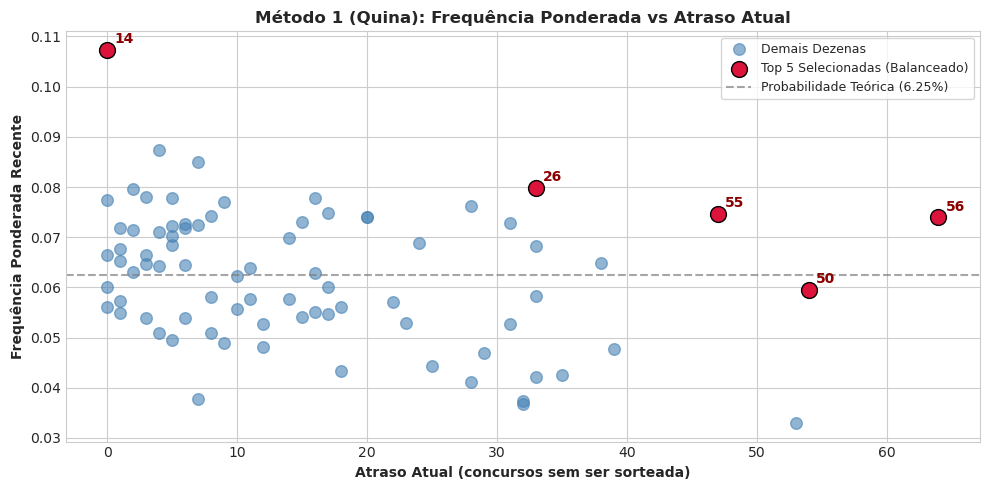

In [2]:
# Treinando o Método 1
m1 = FrequencyDelayModel(half_life=100.0, alpha=0.5)
m1.fit(binary_matrix)
df_m1 = m1.get_scores_df()

pred_m1_bal = m1.predict_top_k(5, strategy='balanced')
pred_m1_over = m1.predict_top_k(5, strategy='overdue')
pred_m1_mom = m1.predict_top_k(5, strategy='momentum')

print(f"Top 5 Método 1 (Balanceado): {pred_m1_bal}")
print(f"Top 5 Método 1 (Mais Atrasadas): {pred_m1_over}")
print(f"Top 5 Método 1 (Mais Frequentes Recentes): {pred_m1_mom}")

# Visualização: Atraso Atual vs Frequência Ponderada
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
selected_mask = df_m1['dezena'].isin(pred_m1_bal)

ax.scatter(df_m1.loc[~selected_mask, 'atraso_atual'], 
           df_m1.loc[~selected_mask, 'freq_ponderada'],
           c='steelblue', alpha=0.6, s=70, label='Demais Dezenas')

ax.scatter(df_m1.loc[selected_mask, 'atraso_atual'], 
           df_m1.loc[selected_mask, 'freq_ponderada'],
           c='crimson', edgecolors='black', s=130, zorder=5, label=f'Top 5 Selecionadas (Balanceado)')

for _, r in df_m1[selected_mask].iterrows():
    ax.annotate(f"{int(r['dezena']):02d}", 
                (r['atraso_atual'], r['freq_ponderada']),
                textcoords="offset points", xytext=(5, 5), fontweight='bold', color='darkred')

p_ref = 5 / 80
ax.set_title(f"Método 1 (Quina): Frequência Ponderada vs Atraso Atual", fontsize=12, fontweight='bold')
ax.set_xlabel("Atraso Atual (concursos sem ser sorteada)", fontsize=10, fontweight='bold')
ax.set_ylabel("Frequência Ponderada Recente", fontsize=10, fontweight='bold')
ax.axhline(p_ref, color='gray', linestyle='--', alpha=0.7, label=f'Probabilidade Teórica ({p_ref*100:.2f}%)')
ax.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()


---
## Método 2: Machine Learning Supervisionado Multi-label

### Engenharia de Atributos e Aprendizado com Validação Temporal
Neste método, o desafio de prever as dezenas é modelado como um problema de classificação supervisionada multi-rótulo:

1. **Estratégia *Binary Relevance*:**
   Treinam-se 80 modelos independentes (um para cada dezena $i \in \{1, \dots, 80\}$). Cada modelo aprende a função de probabilidade:
   $$P\left(Y_i^{(t+1)} = 1 \mid \mathbf{x}_i^{(t)}\right)$$

2. **Engenharia de Atributos Sem Vazamento de Dados (*Zero Lookahead Bias*):**
   O vetor de características $\mathbf{x}_i^{(t)}$ para o concurso $t+1$ utiliza **estritamente** os dados acumulados até o concurso $t$:
   - **Atraso corrente:** Número de sorteios consecutivos sem sair até o momento $t$.
   - **Frequências móveis multiescala:** Taxa de aparição nas últimas $W$ rodadas ($W \in \{5, 10, 25, 50, 100\}$ concursos).
   - **Defasagens temporais (*Lags*):** Indicadores binários de saída nos concursos $t$, $t-1$ e $t-2$.
   - **Variável de contexto:** Contagem de dezenas pares sorteadas no concurso anterior.

3. **Modelo e Calibração:**
   Utiliza-se Regressão Logística com regularização $L_2$ ($C=0.1$) para evitar sobreajuste (*overfitting*). As probabilidades brutas estimadas são calibradas e normalizadas para que sua soma corresponda exatamente a 5 dezenas (o número de bolas sorteadas). As 5 dezenas com maiores probabilidades calibradas compõem a aposta.


Top 5 Método 2 (Machine Learning Multi-label): [4, 18, 30, 49, 53]


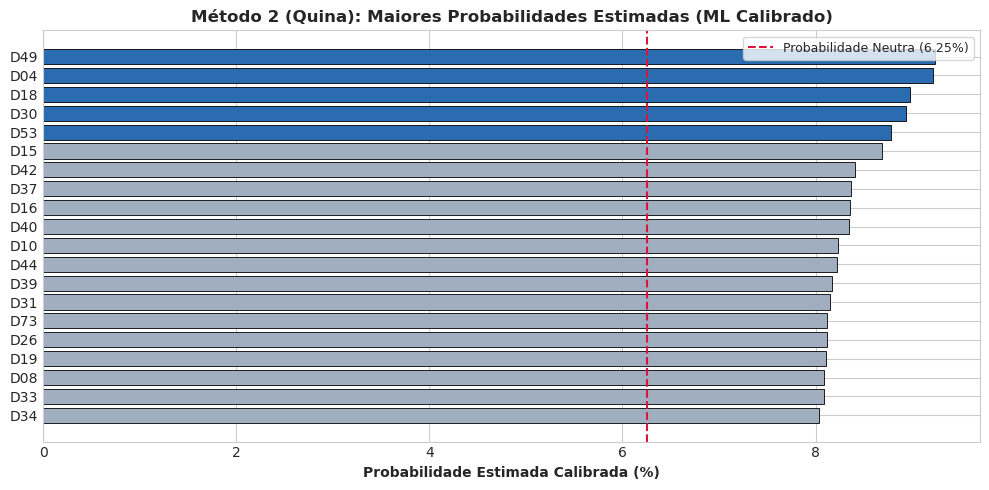

In [3]:
# Treinando o Método 2
m2 = MultiLabelMLModel(estimator='logistic_regression', random_state=42)
m2.fit(binary_matrix)
df_m2 = m2.get_probabilities_df()

pred_m2 = m2.predict_top_k(5)
print(f"Top 5 Método 2 (Machine Learning Multi-label): {pred_m2}")

# Visualização das probabilidades calibradas
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
top_plot_k = min(20, 80)
df_m2_top = df_m2.head(top_plot_k).sort_values('probabilidade_calibrada_sorteio', ascending=True)

bar_colors = ['#2B6CB0' if d in pred_m2 else '#A0AEC0' for d in df_m2_top['dezena']]
bars = ax.barh([f"D{int(d):02d}" for d in df_m2_top['dezena']], 
               df_m2_top['probabilidade_calibrada_sorteio'] * 100, 
               color=bar_colors, edgecolor='black', linewidth=0.6)

p_ref = (5 / 80) * 100
ax.axvline(p_ref, color='crimson', linestyle='--', linewidth=1.5, label=f'Probabilidade Neutra ({p_ref:.2f}%)')
ax.set_title(f"Método 2 (Quina): Maiores Probabilidades Estimadas (ML Calibrado)", fontsize=12, fontweight='bold')
ax.set_xlabel("Probabilidade Estimada Calibrada (%)", fontsize=10, fontweight='bold')
ax.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()


---
## Método 3: Inferência Bayesiana & Teoria da Decisão

### 1. Formalização do Problema de Decisão $(\mathcal{A}, \Theta, P, U)$
Seguindo os princípios formais da Teoria da Decisão Estatística apresentados por **Esteves, Izbicki e Stern (Capítulo 6)**, estruturamos a aposta da seguinte forma:

* **Espaço de Ações (Decisões) $\mathcal{A}$:** O conjunto de todas as combinações possíveis de apostas $a = \{d_1, \dots, d_5\}$ com $d_j \in \{1, \dots, 80\}$.
* **Espaço de Estados da Natureza $\Theta$:** O resultado real do sorteio $s = \{s_1, \dots, s_5\}$.
* **Medida de Incerteza $P$:** Representada pela distribuição preditiva a posteriori $p(\theta \mid \mathcal{D})$, atualizada a partir do histórico observacional.
* **Função de Utilidade $U(a, s)$:** Recompensa o apostador pelo número de dezenas acertadas:
  $$U(a, s) = |a \cap s| = \sum_{i \in a} \mathbb{I}(i \in s)$$
* **Regra de Decisão de Bayes (Utilidade Esperada):**
  A **Alternativa de Bayes** $a^*$ é a ação que maximiza a utilidade esperada a posteriori:
  $$a^* = \arg\max_{a \in \mathcal{A}} \mathbb{E}[U(a, s) \mid \mathcal{D}] = \arg\max_{a \in \mathcal{A}} \sum_{i \in a} \mathbb{E}[\theta_i \mid \mathcal{D}]$$
  Portanto, a decisão ótima consiste em selecionar as **5 dezenas com as maiores esperanças a posteriori**.

---

### 2. O Modelo Conjugado Beta-Binomial
Para cada dezena $i$, consideramos o sorteio como um processo Bernoulli com taxa desconhecida $\theta_i \in [0, 1]$.

* **Priori Racional Justa:**
  Adota-se uma distribuição a priori $\theta_i \sim \text{Beta}(1.0, 15.0)$, cuja esperança neutra reflete exatamente a probabilidade matemática do jogo:
  $$\mathbb{E}[\theta_i] = \frac{\alpha_0}{\alpha_0 + \beta_0} = \frac{5}{80} = 0.0625 = 0.0625 (6.25%)$$
* **Verossimilhança:** $X_i \mid \theta_i \sim \text{Binomial}(n, \theta_i)$.
* **Posteriori Exata:** Pela propriedade de conjugação:
  $$\theta_i \mid X_i = x_i \sim \text{Beta}(\alpha_0 + x_i, \; \beta_0 + n - x_i)$$
* **Esperança a Posteriori e Intervalo de Credibilidade (95%):**
  $$\mathbb{E}[\theta_i \mid x_i] = \frac{\alpha_0 + x_i}{\alpha_0 + \beta_0 + n}$$

---

### 3. As Duas Abordagens Bayesianas: Global vs. Adaptativo
Calculamos e comparamos duas formulações da decisão bayesiana:
* **Conjugado Global (Histórico Total):** Considera todos os concursos de forma cumulativa com pesos iguais. É altamente estável e mede a tendência estrutural de longo prazo, com intervalos de credibilidade muito estreitos.
* **Dinâmico Adaptativo (Ponderado no Tempo):** Aplica fator de decaimento exponencial (meia-vida de 150 concursos) nas contagens pseudo-amostrais, focando no regime físico recente dos sorteios.


Top 5 Decisão Ótima de Bayes (Conjugado Global): [4, 26, 44, 49, 52]
Top 5 Decisão Ótima de Bayes (Dinâmico Adaptativo): [14, 26, 29, 42, 57]


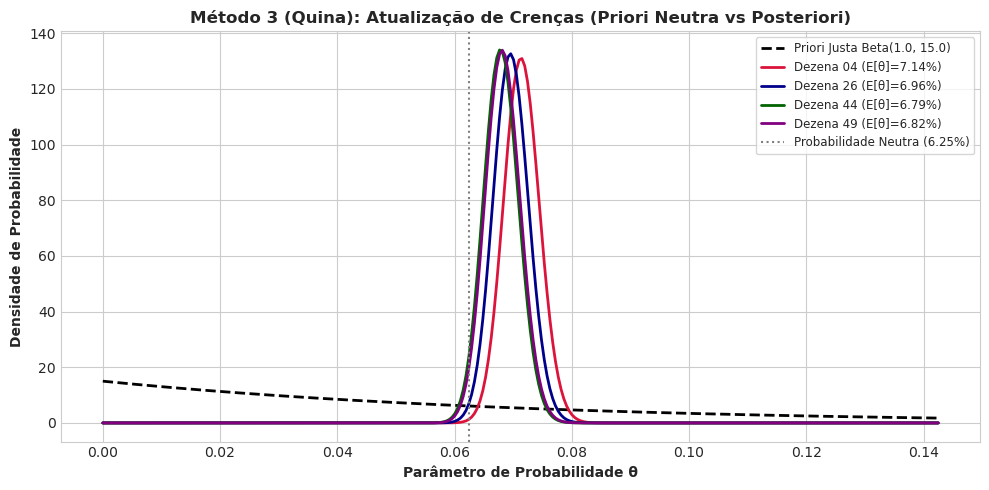

In [4]:
# 3a. Modelo Bayesiano Conjugado Global
m3_static = BayesianDecisionModel(alpha_0=1.0, beta_0=15.0)
m3_static.fit(binary_matrix)
df_m3 = m3_static.get_posterior_df()

pred_m3_static = m3_static.predict_top_k(5)
print(f"Top 5 Decisão Ótima de Bayes (Conjugado Global): {pred_m3_static}")

# 3b. Modelo Bayesiano Dinâmico Adaptativo
m3_dyn = BayesianDecisionModel(alpha_0=1.0, beta_0=15.0, decay_half_life=150.0)
m3_dyn.fit(binary_matrix)
df_m3_dyn = m3_dyn.get_posterior_df()

pred_m3_dyn = m3_dyn.predict_top_k(5)
print(f"Top 5 Decisão Ótima de Bayes (Dinâmico Adaptativo): {pred_m3_dyn}")

# Visualização da Densidade a Posteriori vs Priori
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
theta_vals = np.linspace(max(0, 5/80 - 0.08), min(1, 5/80 + 0.08), 300)

# Priori Neutra
prior_pdf = beta.pdf(theta_vals, 1.0, 15.0)
ax.plot(theta_vals, prior_pdf, 'k--', linewidth=2, label='Priori Justa Beta(1.0, 15.0)')

# Posteriori das top dezenas
sample_dezenas = pred_m3_static[:min(4, len(pred_m3_static))]
colors_top = ['crimson', 'darkblue', 'darkgreen', 'purple']
for d, c in zip(sample_dezenas, colors_top):
    row = df_m3[df_m3['dezena'] == d].iloc[0]
    post_pdf = beta.pdf(theta_vals, row['post_alpha'], row['post_beta'])
    ax.plot(theta_vals, post_pdf, color=c, linewidth=2, label=f"Dezena {int(d):02d} (E[θ]={row['esperanca_posteriori']*100:.2f}%)")

p_ref = 5 / 80
ax.axvline(p_ref, color='gray', linestyle=':', label=f'Probabilidade Neutra ({p_ref*100:.2f}%)')
ax.set_title(f"Método 3 (Quina): Atualização de Crenças (Priori Neutra vs Posteriori)", fontsize=12, fontweight='bold')
ax.set_xlabel("Parâmetro de Probabilidade θ", fontsize=10, fontweight='bold')
ax.set_ylabel("Densidade de Probabilidade", fontsize=10, fontweight='bold')
ax.legend(frameon=True, fontsize=8.5)
plt.tight_layout()
plt.show()


---
## Método 4: A Geometria do Acaso (Gabaritos Diofantinos de Cores — Renato Gianella, 2013)

### Fundamentação Teórica e Formulação Matemática
Em sua obra seminal *The Geometry of Chance: Lotto Numbers Follow a Predicted Pattern* (Revista Brasileira de Biometria, 2013), o matemático e pesquisador **Renato Gianella** introduz uma abordagem analítica que concilia a teoria combinatória com a Lei dos Grandes Números:

1. **Partição em Grupos de Cores:**
   O conjunto universal de dezenas $S_{80}$ é particionado em $C = 8$ grupos disjuntos e regulares de tamanho $g = 10$, cada qual associado a uma cor $c_i$:
   $$(D_0, D_1, \dots, D_{7})$$
   Na **Quina**, temos 8 cores com 10 dezenas cada (01-10, 11-20, ..., 71-80).

2. **A Equação Diofantina Linear:**
   Seja $x_i$ a quantidade de dezenas sorteadas pertencentes ao grupo de cor $i$ ($0 \le x_i \le 10$). Como são sorteadas exatamente $5$ dezenas em cada concurso, a soma das dezenas por cor satisfaz a equação diofantina linear:
   $$\sum_{i=0}^{7} x_i = 5, \quad \text{com } x_i \in \mathbb{N}_{\ge 0}$$

3. **Gabaritos Diofantinos de Cores (Templates):**
   Um gabarito de cores $T$ é uma partição inteira decrescente de $5$ em até $8$ partes:
   $$T = (x_{(1)}, x_{(2)}, \dots, x_{(8)}), \quad \text{onde } x_{(1)} \ge x_{(2)} \ge \dots \ge x_{(8)}$$
   O número total de combinações simples associadas a esse gabarito é dado pelo produto combinatório hipergeométrico multivariado e pela permutação das cores com repetição:
   $$\text{Comb}(T) = \frac{8!}{\prod_{j} m_j!} \cdot \prod_{i=0}^{7} \binom{10}{x_i}$$
   onde $m_j$ é a multiplicidade de cada valor de contagem no gabarito. A probabilidade combinatória teórica de cada macro-estado é:
   $$P(T) = \frac{\text{Comb}(T)}{\binom{80}{5}}$$

4. **Princípio da Invariância do Micro-Estado vs Dispersão do Macro-Estado:**
   - **Micro-Estado:** Qualquer bilhete individual tem rigorosamente a mesma probabilidade $1/\binom{80}{5}$ de ser sorteado em um concurso.
   - **Macro-Estado:** Os gabaritos diofantinos agrupam volumes extremamente desiguais de combinações simples. Gabaritos de alta entropia (dispersão equilibrada entre as cores) concentram de 70% a 90% de todo o espaço amostral, enquanto gabaritos monocromáticos ou fortemente concentrados detêm frações desprezíveis ($< 0.05%$).

5. **A Lei dos Grandes Números e a Regra de Decisão de Gianella:**
   Pela Lei dos Grandes Números de Jacques Bernoulli, as frequências relativas empíricas observadas ao longo da história dos sorteios convergem com precisão matemática para as probabilidades combinatórias teóricas $P(T)$.
   A regra de decisão racional de Gianella preconiza que o apostador deve selecionar bilhetes que **pertençam estritamente ao gabarito mais provável** (macro-estado de maior probabilidade combinatória), preenchendo as cotas das cores mais ativas com as dezenas de maior atratividade empírica e bayesiana.


Top 5 Método 4 (Gianella - Gabarito Diofantino): [4, 16, 31, 52, 56]
Gabarito Teórico Mais Provável: (2, 1, 1, 1, 0, 0, 0, 0)

Principais Gabaritos Diofantinos de Cores (Teórico vs Empírico):
       template  combinacoes  freq_teorica_pct  ocorrencias  freq_empirica_pct   dif_pct
2-1-1-1-0-0-0-0     12600000         52.412611         3725          52.200112 -0.212499
1-1-1-1-1-0-0-0      5600000         23.294494         1688          23.654709  0.360215
2-2-1-0-0-0-0-0      3402000         14.151405         1010          14.153587  0.002183
3-1-1-0-0-0-0-0      2016000          8.386018          570           7.987668 -0.398350
3-2-0-0-0-0-0-0       302400          1.257903          103           1.443386  0.185483
4-1-0-0-0-0-0-0       117600          0.489184           40           0.560538  0.071354


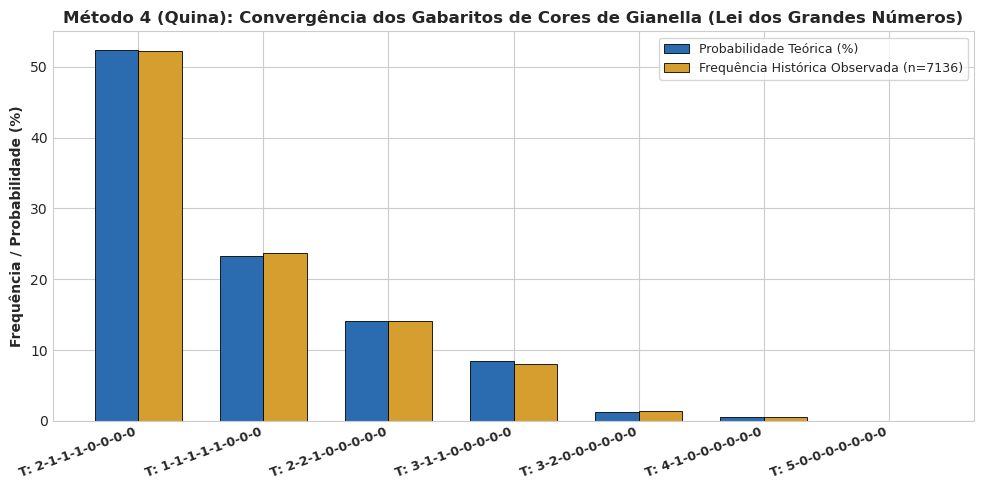

In [5]:
# Treinando o Método 4: A Geometria do Acaso (Gianella)
m4 = GianellaColorTemplateModel(n_dezenas=80, k=5, group_size=10)
m4.fit(binary_matrix)
df_templates = m4.get_template_stats_df()

pred_m4 = m4.predict_top_k(5)
print(f"Top 5 Método 4 (Gianella - Gabarito Diofantino): {pred_m4}")
print(f"Gabarito Teórico Mais Provável: {m4.top_template_}")

# Exibição dos principais gabaritos
print("\nPrincipais Gabaritos Diofantinos de Cores (Teórico vs Empírico):")
display_cols = ['template', 'combinacoes', 'freq_teorica_pct', 'ocorrencias', 'freq_empirica_pct', 'dif_pct']
print(df_templates[display_cols].head(6).to_string(index=False))

# Gráfico Comparativo: Probabilidade Teórica vs Frequência Empírica (Lei dos Grandes Números)
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
top_plot_templates = df_templates.head(min(7, len(df_templates)))
x_pos = np.arange(len(top_plot_templates))
bar_w = 0.35

ax.bar(x_pos - bar_w/2, top_plot_templates['freq_teorica_pct'], width=bar_w, 
       label='Probabilidade Teórica (%)', color='#2B6CB0', edgecolor='black', linewidth=0.6)
ax.bar(x_pos + bar_w/2, top_plot_templates['freq_empirica_pct'], width=bar_w, 
       label=f'Frequência Histórica Observada (n={n_sorteios})', color='#D69E2E', edgecolor='black', linewidth=0.6)

ax.set_xticks(x_pos)
ax.set_xticklabels([f"T: {t}" for t in top_plot_templates['template']], rotation=20, ha='right', fontsize=9, fontweight='bold')
ax.set_title(f"Método 4 (Quina): Convergência dos Gabaritos de Cores de Gianella (Lei dos Grandes Números)", fontsize=12, fontweight='bold')
ax.set_ylabel("Frequência / Probabilidade (%)", fontsize=10, fontweight='bold')
ax.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()


---
## Comparação Consolidada dos 4 Métodos Analíticos
Abaixo sintetizamos as 5 dezenas recomendadas por cada uma das **7 abordagens analíticas e subestratégias** implementadas:
1. **Método 1 (Estatístico - Balanceado):** Z-Score ponderado entre frequência exponencial e atraso relativo.
2. **Método 1 (Mais Atrasadas):** Foco puro em déficit empírico e gap temporal.
3. **Método 1 (Mais Frequentes Recentes):** Foco em aceleração e momento recente (*momentum*).
4. **Método 2 (Machine Learning Multi-label Calibrado):** Regressão logística com *Zero Lookahead Bias* e calibração estocástica.
5. **Método 3 (Bayesiano Conjugado Global):** Modelo Beta-Binomial sobre o histórico total com priori racional neutra.
6. **Método 3 (Bayesiano Dinâmico Adaptativo):** Modelo Beta-Binomial com evidência ponderada no tempo (regime mecânico recente).
7. **Método 4 (Gianella - Geometria do Acaso):** Aposta condicionada ao gabarito diofantino ótimo de cores de maior probabilidade combinatória.

Identificamos a **análise de consenso** (dezenas com convergência de múltiplos modelos independentes) para estruturar a decisão final.


In [6]:
# Execução de todos os métodos analíticos de forma consolidada
results = run_all_lottery_methods(EXCEL_PATH, game='quina', next_concurso=next_concurso)
comp_df = results['comparison_df']

print("=" * 85)
print(f"QUADRO COMPARATIVO OFICIAL DE ESTIMATIVAS — QUINA (CONCURSO {next_concurso})")
print("=" * 85)
for _, r in comp_df.iterrows():
    print(f"• {r['Metodo']:<50} -> [{r['Dezenas Previstas']}]")
print("=" * 85)

# Apuração de Consenso entre os 7 Modelos
vote_counts = {}
for name_m, nums in results['predictions'].items():
    for d in nums:
        vote_counts[d] = vote_counts.get(d, 0) + 1

post_df_ref = results['m3_static'].get_posterior_df().set_index('dezena')
sorted_consensus = sorted(vote_counts.items(), 
                          key=lambda x: (x[1], post_df_ref.loc[x[0], 'esperanca_posteriori']), 
                          reverse=True)
bet_consenso = sorted([x[0] for x in sorted_consensus[:5]])

print(f"★ DECISÃO ÓTIMA DE BAYES (Consenso Multi-modelo): {bet_consenso}")


QUADRO COMPARATIVO OFICIAL DE ESTIMATIVAS — QUINA (CONCURSO 7137)
• Metodo 1 (Estatistico - Balanceado)                -> [14, 26, 50, 55, 56]
• Metodo 1 (Sub-estrategia Mais Atrasadas)           -> [45, 50, 52, 55, 56]
• Metodo 1 (Sub-estrategia Mais Frequentes Recentes) -> [14, 26, 42, 54, 57]
• Metodo 2 (Machine Learning Multi-label Calibrado)  -> [04, 18, 30, 49, 53]
• Metodo 3 (Bayesiano Conjugado Global)              -> [04, 26, 44, 49, 52]
• Metodo 3 (Bayesiano Dinamico Adaptativo)           -> [14, 26, 29, 42, 57]
• Metodo 4 (Gianella - Geometria do Acaso)           -> [04, 16, 31, 52, 56]
★ DECISÃO ÓTIMA DE BAYES (Consenso Multi-modelo): [4, 14, 26, 52, 56]


---
## Considerações Críticas, Ética e Limitações Metodológicas

### 1. Retorno Esperado Estritamente Negativo e a Falácia do Apostador
Como demonstram **Arthur da Costa Almeida e Allan Teixeira Almeida (2020)** em seu estudo computacional sobre as loterias federais:
* **Estrutura de Repasse:** A arrecadação bruta das loterias da Caixa é repartida por lei: cerca de **56% a 57%** é compulsoriamente destinada a repasses sociais (seguridade social, segurança pública, educação, esporte e cultura) e custos operacionais, retornando apenas **43.35% a 45%** aos apostadores como premiação bruta.
* **Esperança Matemática:** Consequentemente, para qualquer combinação e qualquer modalidade, o retorno financeiro esperado é estritamente negativo:
  $$\mathbb{E}[\text{Retorno Financeiro}] < 0 \quad (\approx -55\%)$$
* **Equiprobabilidade dos Micro-Estados:** Nenhuma técnica de inteligência artificial, inferência bayesiana ou análise combinatória é capaz de alterar a probabilidade *ex ante* de um bilhete individual em um jogo justo:
  $$P(\text{combinação}) = \frac{1}{\binom{80}{5}}$$
  Qualquer crença em "números que devem sair" incorre na **Falácia do Apostador (*Gambler's Fallacy*)**.

### 2. O Papel Científico da Teoria da Decisão
Como ensinam os professores **Luís Gustavo Esteves, Rafael Izbicki e Rafael Bassi Stern**, a modelagem formal de decisões sob incerteza **não visa prometer riqueza nem adivinhar o futuro**. Seu valor científico reside em:
- **Racionalidade Axiomática:** Substituir palpites aleatórios por uma formulação coerente de preferências e maximização de utilidade esperada.
- **Transparência Epistêmica:** O método bayesiano explicita quantitativamente a incerteza residual por meio de Intervalos de Credibilidade a 95%, impedindo falsas promessas determinísticas.
- **Consenso Estruturado:** A combinação entre modelos de longo prazo (estáticos), regimes dinâmicos (adaptativos), aprendizado de máquina e gabaritos diofantinos (Gianella) oferece o mais alto grau de consistência matemática possível diante dos dados empíricos observados.

---
### Referências Bibliográficas
* **ALMEIDA, Arthur da Costa; ALMEIDA, Allan Teixeira.** *Simulação Computacional: um estudo de caso com as loterias federais*. Revista Científica Multidisciplinar Núcleo do Conhecimento, ano 05, ed. 10, vol. 08, pp. 176-192, out. 2020. ISSN: 2448-0959.
* **BARBOSA, Fernando; LOPES, Laís C. R. S.; CRUCIOL, Mikaely.** *Preditor de números para Lotofácil: uma abordagem usando algoritmos evolutivos*. Anais do Congresso Nacional de Computação Aplicada, Urutaí, 2013.
* **ESTEVES, Luís Gustavo; IZBICKI, Rafael; STERN, Rafael Bassi.** *Inferência Bayesiana: Notas de Aula*. IME-USP / Departamento de Estatística da UFSCar, São Carlos / São Paulo.
* **GIANELLA, Renato.** *The Geometry of Chance: Lotto Numbers Follow a Predicted Pattern*. Revista Brasileira de Biometria, São Paulo, v. 31, n. 4, p. 582-597, 2013.
* **IZBICKI, Rafael; SANTOS, Tiago Mendonça dos.** *Aprendizado de máquina: uma abordagem estatística*. 1. ed. São Paulo, 2020.


---
## Painel Decisório Final e Recomendação para o Próximo Concurso
A célula a seguir consolida a decisão sob incerteza e gera o **painel visual definitivo de recomendação** para os possíveis números do próximo concurso, integrando:
1. **Consenso Multicritério:** Ranking e frequência de voto entre os 7 métodos analíticos e subestratégias;
2. **Inferência Bayesiana:** Esperança a posteriori e Intervalos de Credibilidade (95%) para as dezenas recomendadas;
3. **Geometria do Acaso:** Distribuição empírica no volante em conformidade com o macro-estado diofantino de Renato Gianella;
4. **Síntese Decisória:** Cartão oficial do bilhete recomendado e quadro completo de apostas geradas por cada abordagem analítica.


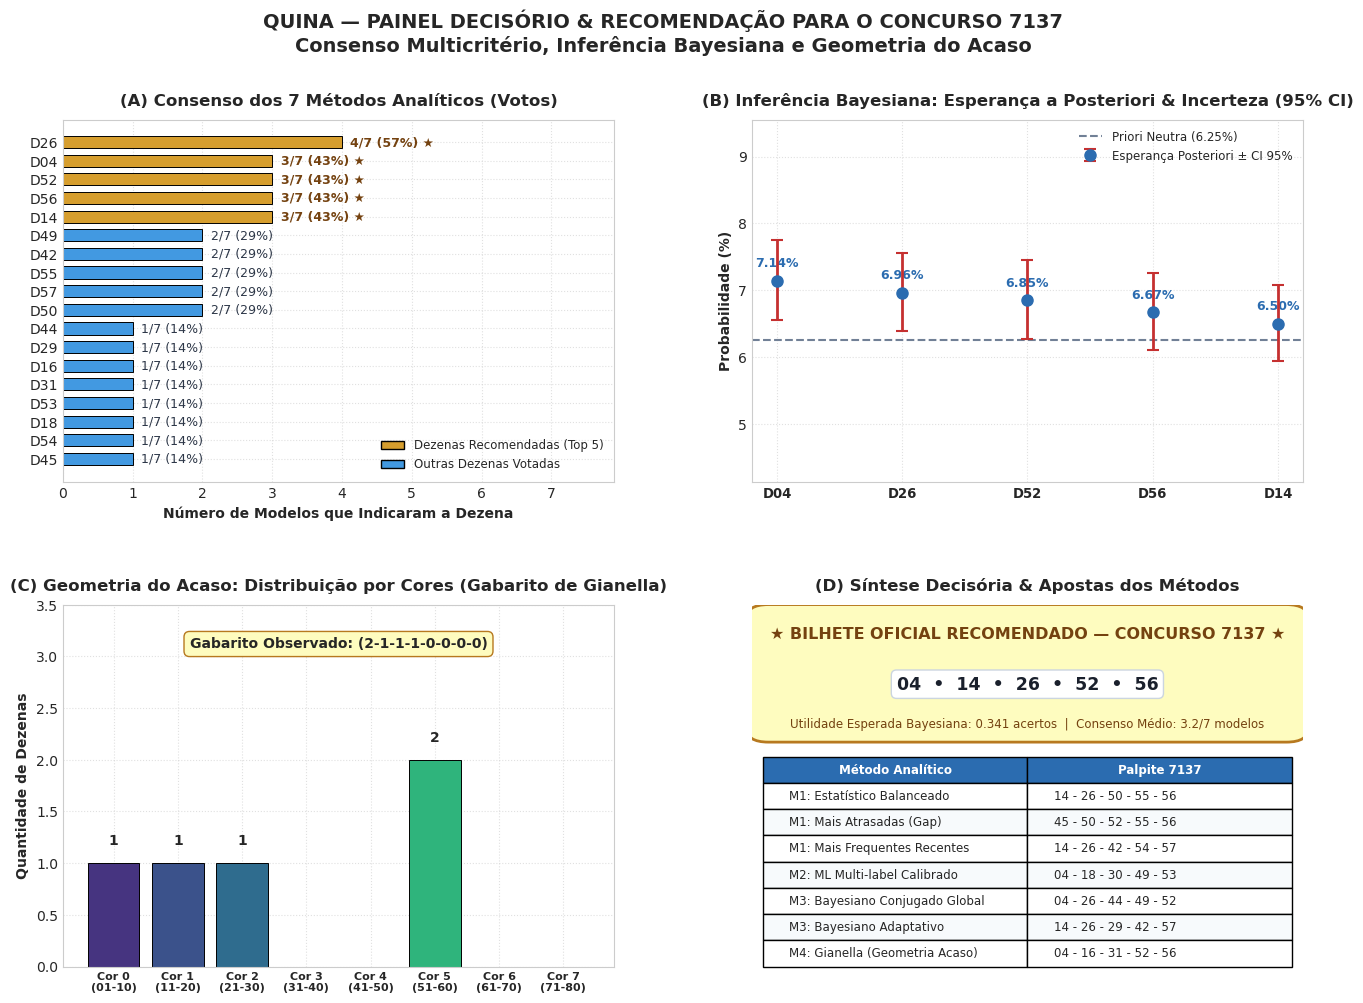

Painel decisório salvo com sucesso em: ..\graficos\quina_7137_dashboard_decisao.png


In [7]:
# ==============================================================================
# PAINEL DECISÓRIO & RECOMENDAÇÃO FINAL PARA O CONCURSO {next_concurso}
# Visualização Sofisticada: Consenso, Inferência Bayesiana e Gabarito de Gianella
# ==============================================================================

fig = plt.figure(figsize=(16, 11), dpi=100)
gs = fig.add_gridspec(2, 2, hspace=0.34, wspace=0.25)

# Extração dos dados consolidados
all_preds = results['predictions']
post_df = results['m3_static'].get_posterior_df().set_index('dezena')
m4_model = results['m4_gianella']
total_metodos = len(all_preds)

# --- (A) Ranking de Consenso entre os Métodos Analíticos ---
ax_a = fig.add_subplot(gs[0, 0])
n_display = min(20, len(sorted_consensus)) if 80 <= 25 else min(18, len(sorted_consensus))
top_display = sorted_consensus[:n_display].copy()
top_display.reverse()
labels_a = [f"D{x[0]:02d}" for x in top_display]
vals_a = [x[1] for x in top_display]
colors_a = ['#D69E2E' if x[0] in bet_consenso else '#4299E1' for x in top_display]

bars_a = ax_a.barh(labels_a, vals_a, color=colors_a, edgecolor='black', linewidth=0.7, height=0.65)
ax_a.set_title(f'(A) Consenso dos {total_metodos} Métodos Analíticos (Votos)', fontsize=12, fontweight='bold', pad=10)
ax_a.set_xlabel('Número de Modelos que Indicaram a Dezena', fontsize=10, fontweight='bold')
ax_a.set_xlim(0, total_metodos + 0.9)
ax_a.grid(True, linestyle=':', alpha=0.6)

for bar, (num, votes) in zip(bars_a, top_display):
    pct = (votes / total_metodos) * 100
    is_top = num in bet_consenso
    tag = " ★" if is_top else ""
    ax_a.text(bar.get_width() + 0.12, bar.get_y() + bar.get_height()/2, 
              f"{votes}/{total_metodos} ({pct:.0f}%){tag}", 
              va='center', fontsize=8.5 if n_display > 18 else 9, 
              fontweight='bold' if is_top else 'normal',
              color='#744210' if is_top else '#2D3748')

legend_elements = [
    patches.Patch(facecolor='#D69E2E', edgecolor='black', label=f'Dezenas Recomendadas (Top 5)'),
    patches.Patch(facecolor='#4299E1', edgecolor='black', label='Outras Dezenas Votadas')
]
ax_a.legend(handles=legend_elements, loc='lower right', fontsize=8.5)

# --- (B) Esperança a Posteriori & Intervalo de Credibilidade (95%) ---
ax_b = fig.add_subplot(gs[0, 1])
top_k_df = post_df.loc[bet_consenso].sort_values('esperanca_posteriori', ascending=False)
x_b = np.arange(len(top_k_df))
means_b = top_k_df['esperanca_posteriori'].values * 100.0
ci_inf_b = top_k_df['ci_95_inf'].values * 100.0
ci_sup_b = top_k_df['ci_95_sup'].values * 100.0
errors_b = [means_b - ci_inf_b, ci_sup_b - means_b]

p_neutra = (5 / 80) * 100.0
ax_b.errorbar(x_b, means_b, yerr=errors_b, fmt='o', color='#2B6CB0', 
             ecolor='#C53030', elinewidth=2, capsize=4, capthick=1.5, 
             markersize=7 if len(top_k_df) > 10 else 8, zorder=4,
             label='Esperança Posteriori ± CI 95%')
ax_b.axhline(p_neutra, color='#718096', linestyle='--', linewidth=1.5, 
             label=f'Priori Neutra ({p_neutra:.2f}%)')
ax_b.set_xticks(x_b)
ax_b.set_xticklabels([f"D{d:02d}" for d in top_k_df.index], 
                     fontsize=8 if len(top_k_df) > 10 else 9.5, 
                     fontweight='bold',
                     rotation=35 if len(top_k_df) > 10 else 0)
ax_b.set_title('(B) Inferência Bayesiana: Esperança a Posteriori & Incerteza (95% CI)', 
               fontsize=12, fontweight='bold', pad=10)
ax_b.set_ylabel('Probabilidade (%)', fontsize=10, fontweight='bold')
ax_b.legend(loc='upper right', fontsize=8.5)
ax_b.grid(True, linestyle=':', alpha=0.6)

y_min_b = min(ci_inf_b) - 1.8
y_max_b = max(ci_sup_b) + 1.8
ax_b.set_ylim(y_min_b, y_max_b)

for idx, (m_val, d_num) in enumerate(zip(means_b, top_k_df.index)):
    y_off = 10 if (idx % 2 == 0 or len(top_k_df) <= 8) else -16
    ax_b.annotate(f"{m_val:.2f}%", (idx, m_val), textcoords="offset points", 
                  xytext=(0, y_off), ha='center', 
                  fontsize=8 if len(top_k_df) > 10 else 9, 
                  fontweight='bold', color='#2B6CB0')

# --- (C) Distribuição no Gabarito Diofantino de Cores de Gianella ---
ax_c = fig.add_subplot(gs[1, 0])
n_colors_cnt = m4_model.n_colors
group_sz = m4_model.group_size
color_counts = [0] * n_colors_cnt
for d in bet_consenso:
    c_idx = (d - 1) // group_sz
    color_counts[c_idx] += 1

palette_c = plt.cm.viridis(np.linspace(0.15, 0.85, n_colors_cnt))
bars_c = ax_c.bar(range(n_colors_cnt), color_counts, color=palette_c, edgecolor='black', linewidth=0.7)
ax_c.set_xticks(range(n_colors_cnt))
color_labels = [f"Cor {i}\n({i*group_sz+1:02d}-{(i+1)*group_sz:02d})" for i in range(n_colors_cnt)]
ax_c.set_xticklabels(color_labels, fontsize=8 if n_colors_cnt > 6 else 8.5, fontweight='bold')
ax_c.set_title(f'(C) Geometria do Acaso: Distribuição por Cores (Gabarito de Gianella)', 
               fontsize=12, fontweight='bold', pad=10)
ax_c.set_ylabel('Quantidade de Dezenas', fontsize=10, fontweight='bold')
max_c = max(color_counts) if max(color_counts) > 0 else 1
ax_c.set_ylim(0, max_c + 1.5)
ax_c.grid(True, linestyle=':', alpha=0.6)

for bar in bars_c:
    h = bar.get_height()
    if h > 0:
        ax_c.text(bar.get_x() + bar.get_width()/2, h + 0.15, f"{int(h)}", 
                  ha='center', va='bottom', fontsize=10, fontweight='bold')

template_str = '-'.join(str(x) for x in sorted(color_counts, reverse=True))
ax_c.text(0.5, 0.88, f"Gabarito Observado: ({template_str})", transform=ax_c.transAxes,
          ha='center', fontsize=10, fontweight='bold', 
          bbox=dict(boxstyle='round,pad=0.4', facecolor='#FEFCBF', edgecolor='#B7791F'))

# --- (D) Síntese Decisória & Bilhete Oficial Recomendado ---
ax_d = fig.add_subplot(gs[1, 1])
ax_d.axis('off')

# Cartão de Aposta Oficial
rect_card = patches.FancyBboxPatch((0.02, 0.65), 0.96, 0.32,
                                   boxstyle="round,pad=0.03,rounding_size=0.04",
                                   facecolor='#FEFCBF', edgecolor='#B7791F', linewidth=2)
ax_d.add_patch(rect_card)

ax_d.text(0.5, 0.92, f"★ BILHETE OFICIAL RECOMENDADO — CONCURSO {next_concurso} ★", 
          fontsize=11.5, fontweight='bold', color='#744210', ha='center', va='center')

if len(bet_consenso) > 10:
    mid_b = (len(bet_consenso) + 1) // 2
    l1 = "  •  ".join(f"{d:02d}" for d in bet_consenso[:mid_b])
    l2 = "  •  ".join(f"{d:02d}" for d in bet_consenso[mid_b:])
    bet_str = f"{l1}\n{l2}"
    bet_y = 0.77
    bet_font = 10.5
else:
    bet_str = "  •  ".join(f"{d:02d}" for d in bet_consenso)
    bet_y = 0.78
    bet_font = 12.5

ax_d.text(0.5, bet_y, bet_str, fontsize=bet_font, fontweight='bold', color='#1A202C', 
          ha='center', va='center', linespacing=1.3,
          bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFFFF', edgecolor='#CBD5E0'))

exp_utility = sum(post_df.loc[d, 'esperanca_posteriori'] for d in bet_consenso)
avg_cons = np.mean([vote_counts[d] for d in bet_consenso])
ax_d.text(0.5, 0.67, f"Utilidade Esperada Bayesiana: {exp_utility:.3f} acertos  |  Consenso Médio: {avg_cons:.1f}/{total_metodos} modelos",
          fontsize=8.5, color='#744210', ha='center', va='center')

# Mapeamento para nomes limpos e elegantes sem truncamento
method_name_map = {
    'Metodo 1 (Estatistico - Balanceado)': 'M1: Estatístico Balanceado',
    'Metodo 1 (Sub-estrategia Mais Atrasadas)': 'M1: Mais Atrasadas (Gap)',
    'Metodo 1 (Sub-estrategia Mais Frequentes Recentes)': 'M1: Mais Frequentes Recentes',
    'Metodo 2 (Machine Learning Multi-label Calibrado)': 'M2: ML Multi-label Calibrado',
    'Metodo 3 (Bayesiano Conjugado Global)': 'M3: Bayesiano Conjugado Global',
    'Metodo 3 (Bayesiano Dinamico Adaptativo)': 'M3: Bayesiano Adaptativo',
    'Metodo 4 (Gianella - Geometria do Acaso)': 'M4: Gianella (Geometria Acaso)',
}

# Quadro Resumo das Apostas (sem truncar dezenas!)
table_data = []
for name_m, bet_list in all_preds.items():
    clean_name = method_name_map.get(name_m, name_m)
    if len(bet_list) > 10:
        mid_m = (len(bet_list) + 1) // 2
        f_bet = " - ".join(f"{d:02d}" for d in bet_list[:mid_m]) + "\n" + " - ".join(f"{d:02d}" for d in bet_list[mid_m:])
    else:
        f_bet = " - ".join(f"{d:02d}" for d in bet_list)
    table_data.append([clean_name, f_bet])

tab = ax_d.table(cellText=table_data, colLabels=["Método Analítico", f"Palpite {next_concurso}"],
                 cellLoc='left', loc='lower center', bbox=[0.02, 0.0, 0.96, 0.58])
tab.auto_set_font_size(False)
tab.set_fontsize(8.0 if len(bet_consenso) > 10 else 8.5)

for (r_idx, c_idx), cell in tab.get_celld().items():
    if r_idx == 0:
        cell.set_facecolor('#2B6CB0')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#FFFFFF' if r_idx % 2 == 1 else '#F7FAFC')
        if c_idx == 1:
            cell.set_text_props(linespacing=1.2)

ax_d.set_title(f'(D) Síntese Decisória & Apostas dos Métodos', fontsize=12, fontweight='bold', pad=10)

fig.suptitle(f"QUINA — PAINEL DECISÓRIO & RECOMENDAÇÃO PARA O CONCURSO {next_concurso}\n"
             f"Consenso Multicritério, Inferência Bayesiana e Geometria do Acaso",
             fontsize=14, fontweight='bold', y=0.98)

# Salvar e exibir
graficos_dir = os.path.join('..', 'graficos') if os.path.exists(os.path.join('..', 'graficos')) else 'graficos'
os.makedirs(graficos_dir, exist_ok=True)
game_prefix = cfg.get('prefix', 'mega_sena' if cfg['n_dezenas'] == 60 else ('lotofacil' if cfg['n_dezenas'] == 25 else 'quina'))
out_fig_path = os.path.join(graficos_dir, f"{game_prefix}_{next_concurso}_dashboard_decisao.png")
fig.savefig(out_fig_path, dpi=120, bbox_inches='tight')
out_fig_generic = os.path.join(graficos_dir, f"{game_prefix}_dashboard_decisao.png")
fig.savefig(out_fig_generic, dpi=120, bbox_inches='tight')
plt.show()
print(f"Painel decisório salvo com sucesso em: {out_fig_path}")
